# ml_cluster_codes  （v2）

本 notebook 为 `ml_cluster_lec.ipynb` 生成模拟数据和配图。

**数据设计**：

| 数据集 | 样本量 | 说明 | 用途 |
|---|:---:|---|---|
| 数据集 C（客户）| 500 | 年均消费额 × 消费频率，3 个规则球形簇 | K-means 主例 |
| 数据集 B（债券）| 200 | 4 维债券特征，4 个簇 | 层次聚类主例 |
| 数据集 N（非球形）| 300 | 月牙形 + 同心圆结构 | K-means 局限演示 |

**图片清单（v2 新增 fig00a / fig04a / fig04b）**：

| 图号 | 文件名 | 布局 | figsize | 说明 |
|---|---|:---:|:---:|---|
| 00a | `ml_cluster_fig00a_intra_inter` | 单图 | (8,4) | 簇内 vs 簇间距离直觉示意（新增）|
| 01 | `ml_cluster_fig01_data_C` | 单图 | (8,5) | 原始散点 |
| 02 | `ml_cluster_fig02_kmeans_iter` | 2×2 | (8,7) | 迭代过程 |
| 03 | `ml_cluster_fig03_kmeans_result` | 单图 | (8,5) | 最终结果 |
| 04 | `ml_cluster_fig04_local_optima` | 三图 | (8,2.8) | 局部最优 |
| 04a | `ml_cluster_fig04a_voronoi_k` | 四图 2×2 | (8,7) | 不同 K 的 Voronoi（新增）|
| 04b | `ml_cluster_fig04b_outlier` | 双图 | (8,4) | 离群值敏感性（新增）|
| 05 | `ml_cluster_fig05_elbow` | 单图 | (8,5) | 肘部法则 |
| 06 | `ml_cluster_fig06_silhouette` | 双图 | (8,4) | 轮廓系数 |
| 06a | `ml_cluster_fig06a_sil_geometry` | 单图 | (8,4.5) | 轮廓系数几何直觉（新增）|
| 07 | `ml_cluster_fig07_dendrogram` | 单图 | (8,5) | 树状图 |
| 08 | `ml_cluster_fig08_linkage` | 三图 | (8,2.8) | 连接方式对比 |
| 09 | `ml_cluster_fig09_cut` | 双图 | (8,4) | 切割高度 |
| 10 | `ml_cluster_fig10_compare` | 双图 | (8,4) | K-means vs 层次聚类 |
| 11 | `ml_cluster_fig11_nonconvex` | 三图 | (8,2.8) | 非球形局限 |
| 12 | `ml_cluster_fig12_pca_cluster` | 双图 | (8,4) | PCA + 聚类 |


In [1]:
# ------------------------------------------------------------
# 0. 全局设置
# ------------------------------------------------------------

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, Circle, FancyBboxPatch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles

warnings.filterwarnings('ignore')
os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)

# ── 中文字体 ──
available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = [
    'SimHei', 'Microsoft YaHei', 'Noto Sans CJK SC',
    'Noto Sans CJK JP', 'WenQuanYi Micro Hei',
    'Arial Unicode MS', 'DejaVu Sans',
]
FONT_FAMILY = next(
    (f for f in font_candidates if f in available_fonts), 'DejaVu Sans'
)
plt.rcParams['font.sans-serif'] = [FONT_FAMILY]
plt.rcParams['axes.unicode_minus'] = False

# ── 全局基础配置（兼容旧版 matplotlib）──
plt.rcParams.update({
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.22,
})

# ── 场景切换函数 ──
def fig_single():
    plt.rcParams.update({
        'figure.figsize': (8, 5), 'font.size': 11,
        'legend.fontsize': 10,   'axes.labelsize': 11,
        'xtick.labelsize': 10,   'ytick.labelsize': 10,
    })

def fig_double():
    plt.rcParams.update({
        'figure.figsize': (8, 4), 'font.size': 10,
        'legend.fontsize': 9,    'axes.labelsize': 10,
        'xtick.labelsize': 9,    'ytick.labelsize': 9,
    })

def fig_triple():
    plt.rcParams.update({
        'figure.figsize': (8, 2.8), 'font.size': 9,
        'legend.fontsize': 8,       'axes.labelsize': 9,
        'xtick.labelsize': 8,       'ytick.labelsize': 8,
    })

def save_fig(fig, basename):
    '''保存 PNG + SVG，bbox_inches 直接在 savefig 传参（兼容旧版 matplotlib）'''
    fig.savefig(f'./figs/{basename}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    fig.savefig(f'./figs/{basename}.svg',
                bbox_inches='tight', facecolor='white')

# ── 配色 ──
PALETTE = ['#1A3A6B', '#C8900A', '#2E8B57', '#CC2222', '#7B3F9E', '#666666']

RNG = np.random.default_rng(2026)
print(f'字体: {FONT_FAMILY}')

字体: SimHei


In [2]:
# ------------------------------------------------------------
# 1. 生成数据集 C：客户消费行为，3 个球形簇
# ------------------------------------------------------------

n_C = 500
centers_C = np.array([[1500, 3.5], [8000, 2.0], [4500, 9.0]])
stds_C    = np.array([[500,  0.6], [900,  0.5], [700,  0.8]])
sizes_C   = [160, 170, 170]

X_C_parts, y_C_parts = [], []
for k, (center, std, size) in enumerate(zip(centers_C, stds_C, sizes_C)):
    pts = RNG.normal(center, std, size=(size, 2))
    X_C_parts.append(pts)
    y_C_parts.append(np.full(size, k))

X_C = np.vstack(X_C_parts)
y_C = np.concatenate(y_C_parts)
perm = RNG.permutation(n_C)
X_C, y_C = X_C[perm], y_C[perm]

df_C = pd.DataFrame(X_C, columns=['annual_spend', 'freq_per_month'])
df_C['true_cluster'] = y_C
df_C.to_csv('./data/cluster_customers.csv', index=False, encoding='utf-8-sig')

scaler_C = StandardScaler()
X_C_sc = scaler_C.fit_transform(X_C)

print(f'数据集 C: {X_C.shape}')

数据集 C: (500, 2)


In [3]:
# ------------------------------------------------------------
# 2. 生成数据集 B：债券特征，4 个簇
# ------------------------------------------------------------

n_B = 200
bond_specs = [
    ([5.0,  0.3,  0.1, 9.0], [0.6, 0.04, 0.02, 0.3], 50, '国债'),
    ([6.5,  1.2,  0.4, 7.0], [0.8, 0.10, 0.05, 0.5], 50, '投资级企业债'),
    ([4.0,  3.8,  1.2, 4.5], [0.9, 0.25, 0.15, 0.6], 50, '高收益债'),
    ([7.5,  2.2,  0.8, 5.5], [1.1, 0.18, 0.10, 0.7], 50, '新兴市场债'),
]
X_B_parts, y_B_parts, bond_names = [], [], []
for k, (center, cov_d, size, name) in enumerate(bond_specs):
    pts = RNG.normal(center, np.sqrt(cov_d), size=(size, 4))
    X_B_parts.append(pts)
    y_B_parts.append(np.full(size, k))
    bond_names.append(name)

X_B = np.vstack(X_B_parts)
y_B = np.concatenate(y_B_parts)
perm_B = RNG.permutation(n_B)
X_B, y_B = X_B[perm_B], y_B[perm_B]

bond_cols = ['duration', 'credit_spread', 'liquidity', 'rating_score']
df_B = pd.DataFrame(X_B, columns=bond_cols)
df_B['true_cluster'] = y_B
df_B.to_csv('./data/cluster_bonds.csv', index=False, encoding='utf-8-sig')

X_B_sc = StandardScaler().fit_transform(X_B)
Z_ward = linkage(X_B_sc, method='ward')
pca_B  = PCA(n_components=2)
X_B_2d = pca_B.fit_transform(X_B_sc)

print(f'数据集 B: {X_B.shape}')

数据集 B: (200, 4)


In [4]:
# ------------------------------------------------------------
# 3. 生成数据集 N：非球形结构
# ------------------------------------------------------------

X_moon, y_moon = make_moons(n_samples=200, noise=0.08, random_state=42)
X_circ, y_circ = make_circles(n_samples=200, noise=0.06,
                               factor=0.45, random_state=42)

theta = RNG.uniform(0, 2*np.pi, 150)
r1    = 0.15 + RNG.normal(0, 0.03, 150)
x1    = 3*r1*np.cos(theta) + RNG.normal(0, 0.05, 150)
x2    = 0.4*r1*np.sin(theta) + RNG.normal(0, 0.05, 150)
X_elong = np.vstack([np.c_[x1, x2], np.c_[-x2, x1]])
y_elong = np.r_[np.zeros(150), np.ones(150)].astype(int)

print('非球形数据集生成完毕')

非球形数据集生成完毕


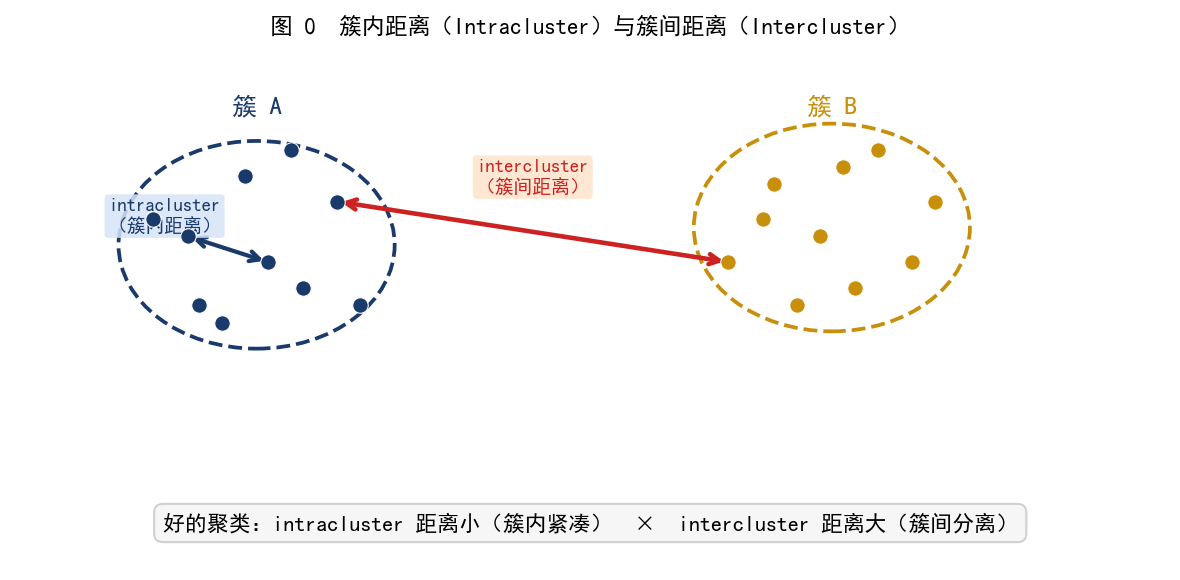

In [5]:
# ------------------------------------------------------------
# 图 00a：Intracluster vs Intercluster 距离直觉示意（新增）
# ml_cluster_fig00a_intra_inter
# ------------------------------------------------------------

fig_single()
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# ── 簇 A（左，蓝色）──
pts_A = np.array([[1.5,3.8],[2.0,4.5],[2.5,3.2],[1.8,2.8],[2.8,4.2],
                  [1.2,4.0],[2.2,3.5],[3.0,3.0],[1.6,3.0],[2.4,4.8]])
ax.scatter(pts_A[:,0], pts_A[:,1], color=PALETTE[0], s=55, zorder=4,
           edgecolors='white', linewidths=0.5)
circle_A = Circle((2.1, 3.7), 1.2, fill=False,
                   edgecolor=PALETTE[0], linewidth=1.8, linestyle='--')
ax.add_patch(circle_A)
ax.text(2.1, 5.2, '簇 A', ha='center', fontsize=12,
        color=PALETTE[0], fontweight='bold')

# ── 簇 B（右，黄色）──
pts_B = np.array([[6.5,4.0],[7.2,4.6],[7.8,3.5],[6.8,3.0],[7.5,4.8],
                  [6.2,3.5],[7.0,3.8],[8.0,4.2],[6.6,4.4],[7.3,3.2]])
ax.scatter(pts_B[:,0], pts_B[:,1], color=PALETTE[1], s=55, zorder=4,
           edgecolors='white', linewidths=0.5)
circle_B = Circle((7.1, 3.9), 1.2, fill=False,
                   edgecolor=PALETTE[1], linewidth=1.8, linestyle='--')
ax.add_patch(circle_B)
ax.text(7.1, 5.2, '簇 B', ha='center', fontsize=12,
        color=PALETTE[1], fontweight='bold')

# ── 簇内距离（intracluster）：簇 A 内两点连线 ──
i1, i2 = 0, 6
ax.annotate('', xy=pts_A[i2], xytext=pts_A[i1],
            arrowprops=dict(arrowstyle='<->', color=PALETTE[0],
                            lw=2.0, mutation_scale=12))
mid_a = (pts_A[i1] + pts_A[i2]) / 2
ax.text(mid_a[0]-0.55, mid_a[1]+0.2,
        'intracluster\n（簇内距离）',
        fontsize=9, color=PALETTE[0], ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#D6E4F7',
                  alpha=0.85, edgecolor='none'))

# ── 簇间距离（intercluster）：两簇各一点连线 ──
p_a = pts_A[4]   # 簇A最右点
p_b = pts_B[5]   # 簇B最左点
ax.annotate('', xy=p_b, xytext=p_a,
            arrowprops=dict(arrowstyle='<->', color=PALETTE[3],
                            lw=2.2, mutation_scale=12))
mid_ab = (p_a + p_b) / 2
ax.text(mid_ab[0], mid_ab[1]+0.45,
        'intercluster\n（簇间距离）',
        fontsize=9, color=PALETTE[3], ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFE5CC',
                  alpha=0.85, edgecolor='none'))

# ── 底部说明 ──
ax.text(5.0, 0.4,
        '好的聚类：intracluster 距离小（簇内紧凑）  ×  intercluster 距离大（簇间分离）',
        ha='center', fontsize=10.5,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5',
                  edgecolor='#cccccc', alpha=0.9))

ax.set_title('图 0  簇内距离（Intracluster）与簇间距离（Intercluster）',
             fontsize=11)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig00a_intra_inter')
plt.show()

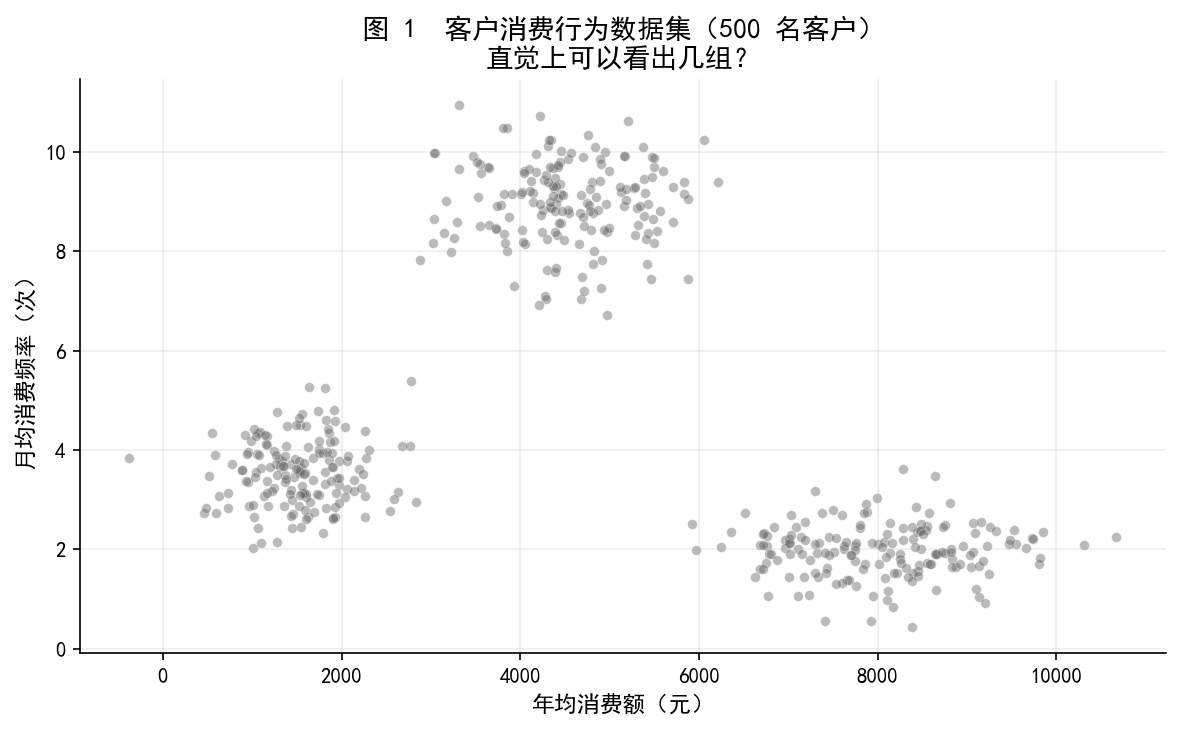

In [6]:
# ------------------------------------------------------------
# 图 01：数据集 C 原始散点图
# ml_cluster_fig01_data_C
# ------------------------------------------------------------

fig_single()
fig, ax = plt.subplots()
ax.scatter(X_C[:,0], X_C[:,1], color='#666666', alpha=0.45, s=22,
           edgecolors='white', linewidths=0.3)
ax.set_xlabel('年均消费额（元）')
ax.set_ylabel('月均消费频率（次）')
ax.set_title('图 1  客户消费行为数据集（500 名客户）\n直觉上可以看出几组？')
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig01_data_C')
plt.show()

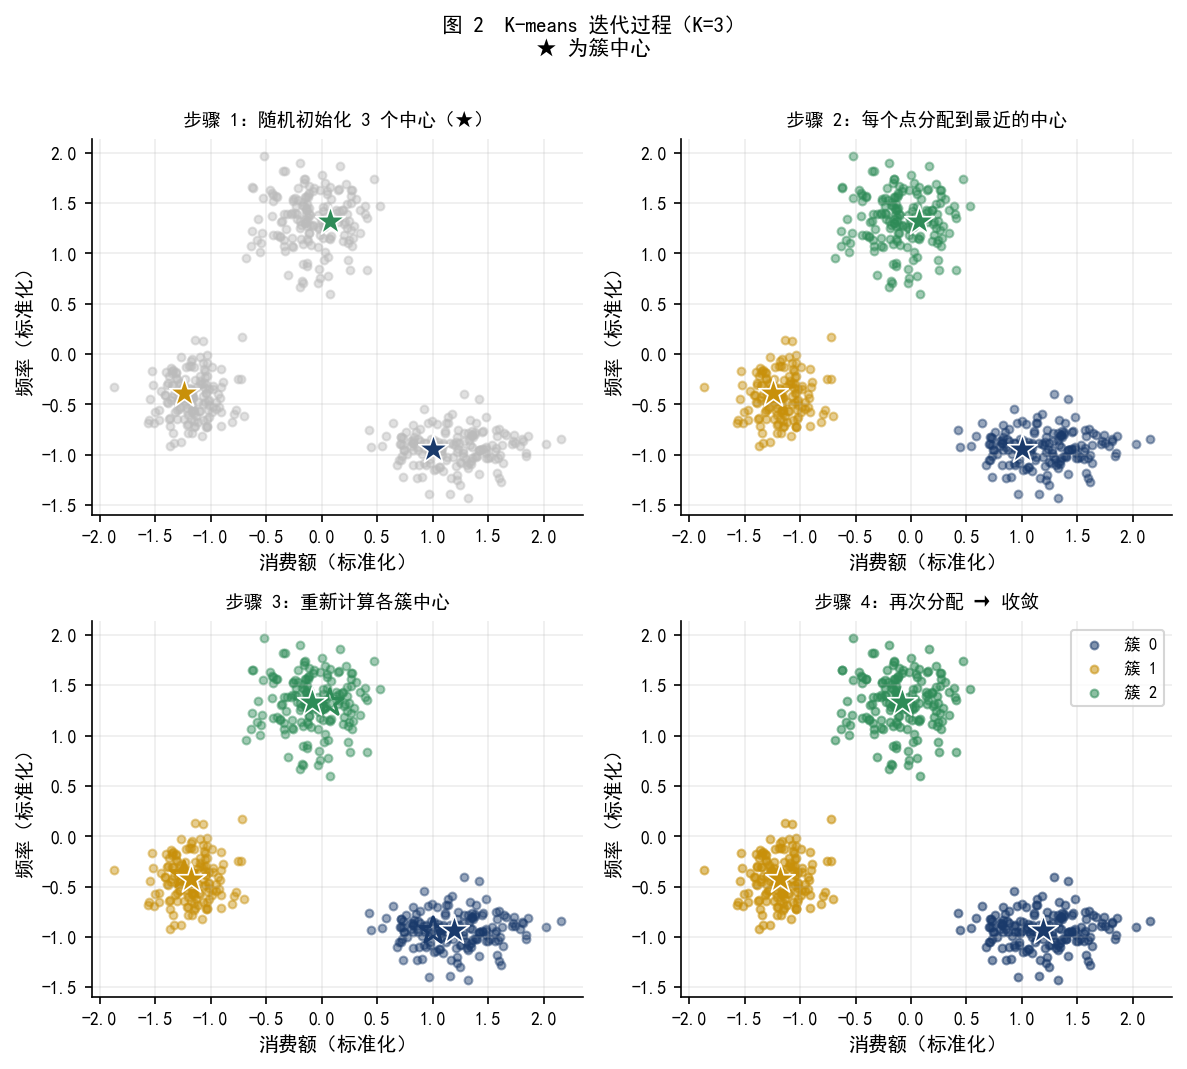

In [7]:
# ------------------------------------------------------------
# 图 02：K-means 迭代过程（4 步）
# ml_cluster_fig02_kmeans_iter
# ------------------------------------------------------------

def assign_clusters(X, centers):
    dists = np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2)
    return np.argmin(dists, axis=1)

def update_centers(X, labels, K):
    return np.array([X[labels==k].mean(axis=0) for k in range(K)])

K = 3
init_centers = X_C_sc[[12, 180, 350]].copy()

plt.rcParams.update({
    'figure.figsize': (8, 7), 'font.size': 9.5,
    'legend.fontsize': 8.5,  'axes.labelsize': 9.5,
    'xtick.labelsize': 8.5,  'ytick.labelsize': 8.5,
})

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

centers = init_centers.copy()
step_titles = [
    '步骤 1：随机初始化 3 个中心（★）',
    '步骤 2：每个点分配到最近的中心',
    '步骤 3：重新计算各簇中心',
    '步骤 4：再次分配 → 收敛',
]

for step, (ax, title) in enumerate(zip(axes, step_titles)):
    if step == 0:
        ax.scatter(X_C_sc[:,0], X_C_sc[:,1],
                   color='#bbbbbb', alpha=0.45, s=14)
        for k, c in enumerate(centers):
            ax.scatter(*c, marker='*', s=220, color=PALETTE[k],
                       zorder=5, edgecolors='white', linewidths=0.8)
    elif step == 1:
        labels = assign_clusters(X_C_sc, centers)
        for k in range(K):
            ax.scatter(X_C_sc[labels==k,0], X_C_sc[labels==k,1],
                       color=PALETTE[k], alpha=0.45, s=14)
        for k, c in enumerate(centers):
            ax.scatter(*c, marker='*', s=220, color=PALETTE[k],
                       zorder=5, edgecolors='white', linewidths=0.8)
    elif step == 2:
        labels = assign_clusters(X_C_sc, centers)
        new_centers = update_centers(X_C_sc, labels, K)
        for k in range(K):
            ax.scatter(X_C_sc[labels==k,0], X_C_sc[labels==k,1],
                       color=PALETTE[k], alpha=0.45, s=14)
        for k in range(K):
            ax.scatter(*centers[k], marker='*', s=180,
                       facecolors='none', edgecolors=PALETTE[k],
                       linewidths=1.5, zorder=4)
            ax.annotate('', xy=new_centers[k], xytext=centers[k],
                        arrowprops=dict(arrowstyle='->',
                                        color=PALETTE[k], lw=1.5))
            ax.scatter(*new_centers[k], marker='*', s=220,
                       color=PALETTE[k], zorder=5,
                       edgecolors='white', linewidths=0.8)
        centers = new_centers
    else:
        labels = assign_clusters(X_C_sc, centers)
        for k in range(K):
            ax.scatter(X_C_sc[labels==k,0], X_C_sc[labels==k,1],
                       color=PALETTE[k], alpha=0.55, s=14,
                       label=f'簇 {k}')
        for k, c in enumerate(centers):
            ax.scatter(*c, marker='*', s=220, color=PALETTE[k],
                       zorder=5, edgecolors='white', linewidths=0.8)
        ax.legend(fontsize=8, loc='upper right')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('消费额（标准化）')
    ax.set_ylabel('频率（标准化）')

fig.suptitle('图 2  K-means 迭代过程（K=3）\n★ 为簇中心',
             fontsize=10, y=1.01)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig02_kmeans_iter')
plt.show()

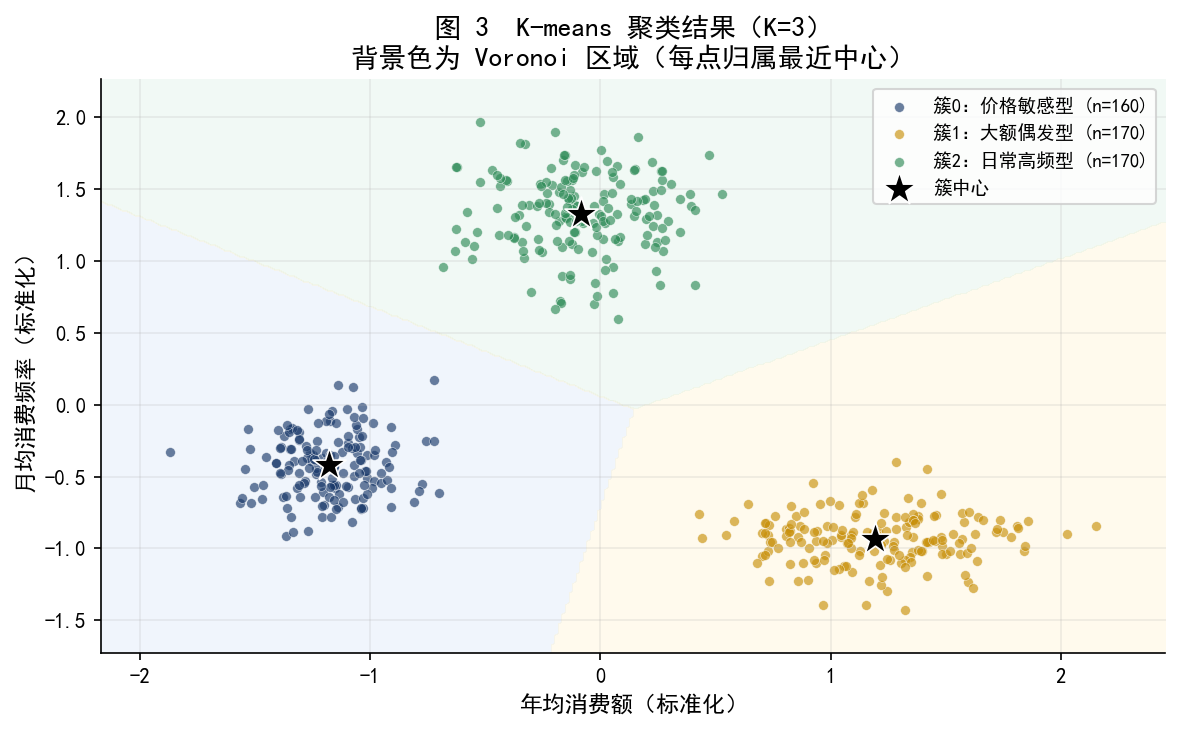

WCSS = 58.93


In [8]:
# ------------------------------------------------------------
# 图 03：K-means 最终聚类结果
# ml_cluster_fig03_kmeans_result
# ------------------------------------------------------------

fig_single()

km_final = KMeans(n_clusters=3, n_init=20, random_state=42)
km_final.fit(X_C_sc)
labels_C = km_final.labels_
centers_final = km_final.cluster_centers_

x_min, x_max = X_C_sc[:,0].min()-0.3, X_C_sc[:,0].max()+0.3
y_min, y_max = X_C_sc[:,1].min()-0.3, X_C_sc[:,1].max()+0.3
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300),
                      np.linspace(y_min,y_max,300))
Z = km_final.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

bg_cmap = ListedColormap(['#D6E4F7','#FFF3CC','#D8F0E4'])

fig, ax = plt.subplots()
ax.contourf(xx,yy,Z, levels=[-0.5,0.5,1.5,2.5],
            cmap=bg_cmap, alpha=0.35, zorder=0)

cluster_labels_cn = ['价格敏感型','大额偶发型','日常高频型']
for k in range(3):
    mask = labels_C == k
    ax.scatter(X_C_sc[mask,0], X_C_sc[mask,1],
               color=PALETTE[k], alpha=0.65, s=22,
               edgecolors='white', linewidths=0.3,
               label=f'簇{k}：{cluster_labels_cn[k]} (n={mask.sum()})')
ax.scatter(centers_final[:,0], centers_final[:,1],
           marker='*', s=280, color='black', zorder=5,
           edgecolors='white', linewidths=0.8, label='簇中心')
ax.set_xlabel('年均消费额（标准化）')
ax.set_ylabel('月均消费频率（标准化）')
ax.set_title('图 3  K-means 聚类结果（K=3）\n'
             '背景色为 Voronoi 区域（每点归属最近中心）')
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig03_kmeans_result')
plt.show()
print(f'WCSS = {km_final.inertia_:.2f}')

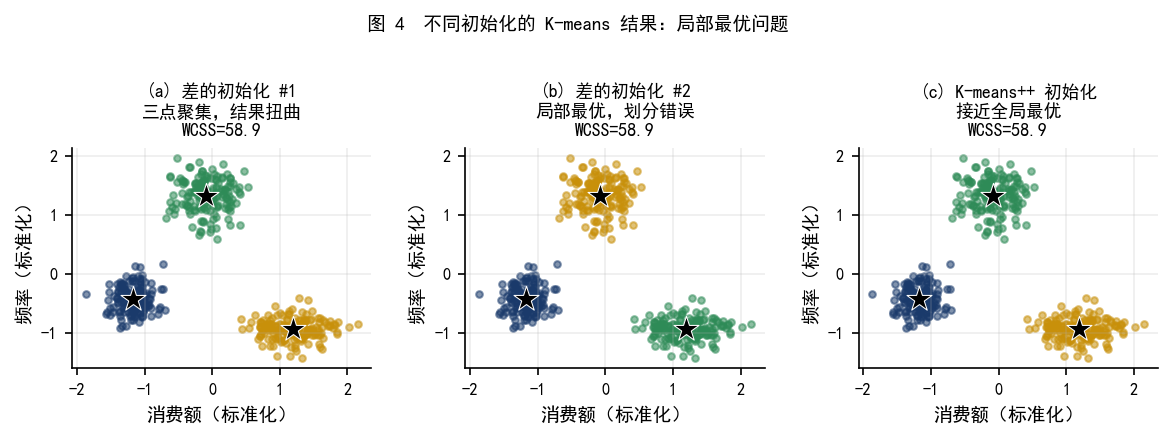

In [9]:
# ------------------------------------------------------------
# 图 04：局部最优问题
# ml_cluster_fig04_local_optima
# ------------------------------------------------------------

fig_triple()

bad_inits = [
    np.array([[-0.5,-0.5],[-0.4,-0.4],[-0.3,-0.3]]),
    np.array([[-1.5,1.5],[1.5,1.5],[0.0,-1.5]]),
]

fig, axes = plt.subplots(1, 3)

for ax, (init_type, title) in zip(axes, [
    ('bad1', '(a) 差的初始化 #1\n三点聚集，结果扭曲'),
    ('bad2', '(b) 差的初始化 #2\n局部最优，划分错误'),
    ('good', '(c) K-means++ 初始化\n接近全局最优'),
]):
    if init_type == 'bad1':
        km = KMeans(n_clusters=3, init=bad_inits[0], n_init=1, random_state=0)
    elif init_type == 'bad2':
        km = KMeans(n_clusters=3, init=bad_inits[1], n_init=1, random_state=0)
    else:
        km = KMeans(n_clusters=3, init='k-means++', n_init=1, random_state=42)
    km.fit(X_C_sc)
    lbls, inertia = km.labels_, km.inertia_
    for k in range(3):
        ax.scatter(X_C_sc[lbls==k,0], X_C_sc[lbls==k,1],
                   color=PALETTE[k], alpha=0.55, s=10)
    ax.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
               marker='*', s=160, color='black', zorder=5,
               edgecolors='white', linewidths=0.5)
    ax.set_title(f'{title}\nWCSS={inertia:.1f}', fontsize=8.5)
    ax.set_xlabel('消费额（标准化）')
    ax.set_ylabel('频率（标准化）')

fig.suptitle('图 4  不同初始化的 K-means 结果：局部最优问题',
             fontsize=9, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig04_local_optima')
plt.show()

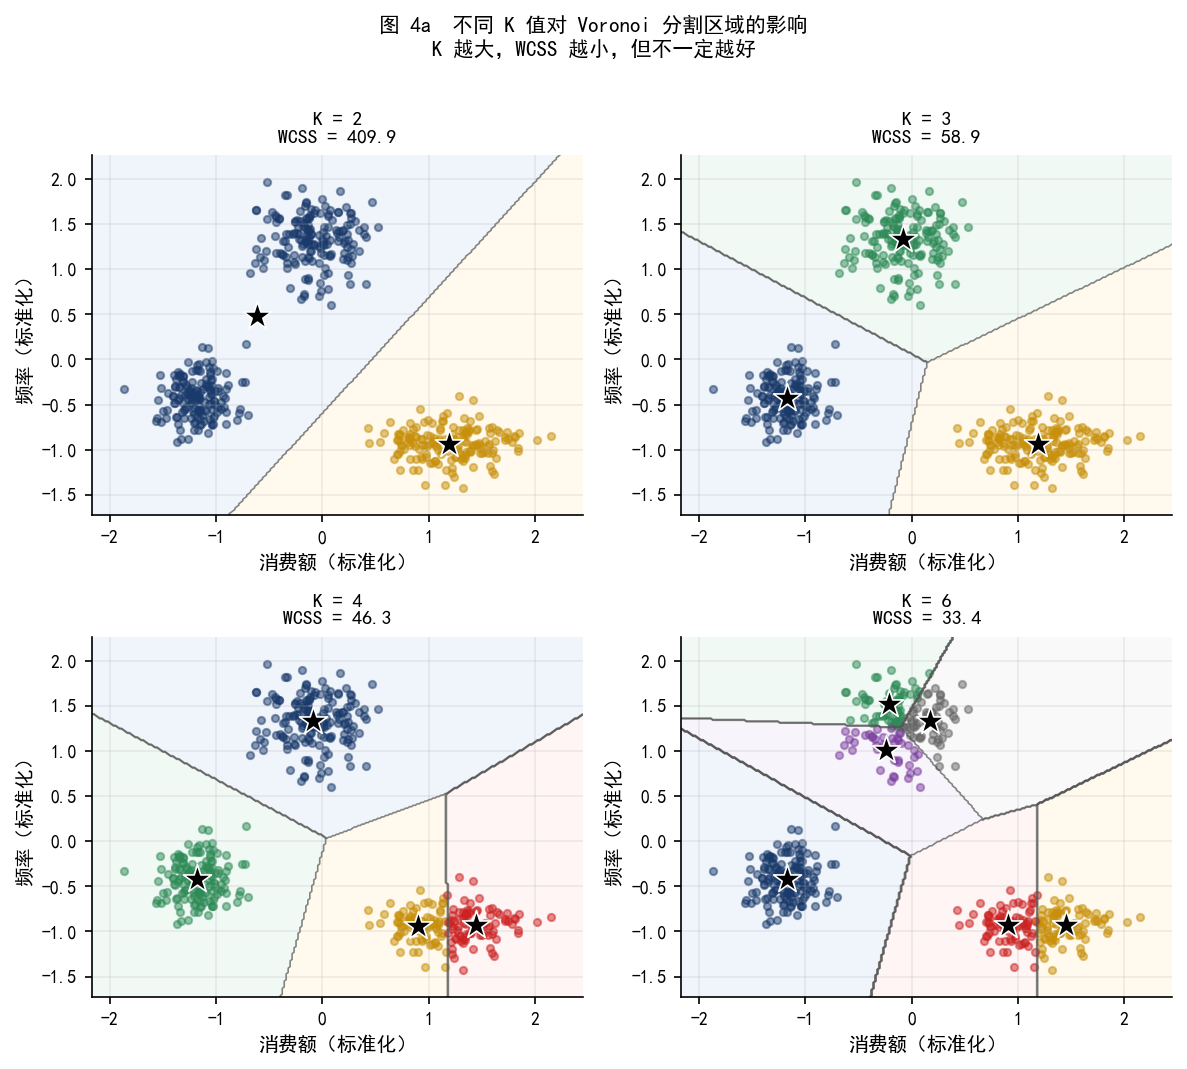

In [10]:
# ------------------------------------------------------------
# 图 04a：不同 K 的 Voronoi 分割（新增）
# ml_cluster_fig04a_voronoi_k
# ------------------------------------------------------------

plt.rcParams.update({
    'figure.figsize': (8, 7), 'font.size': 9.5,
    'legend.fontsize': 8.5,  'axes.labelsize': 9.5,
    'xtick.labelsize': 8.5,  'ytick.labelsize': 8.5,
})

K_list = [2, 3, 4, 6]
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

x_min, x_max = X_C_sc[:,0].min()-0.3, X_C_sc[:,0].max()+0.3
y_min, y_max = X_C_sc[:,1].min()-0.3, X_C_sc[:,1].max()+0.3
xx, yy = np.meshgrid(np.linspace(x_min,x_max,250),
                      np.linspace(y_min,y_max,250))

for ax, K_val in zip(axes, K_list):
    km_k = KMeans(n_clusters=K_val, n_init=20, random_state=42)
    km_k.fit(X_C_sc)
    lbls_k = km_k.labels_
    Z_k = km_k.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

    # 背景色（最多 6 色）
    bg_colors = ['#D6E4F7','#FFF3CC','#D8F0E4','#FFE5E5','#EDE0F5','#EEEEEE']
    bg_cmap_k = ListedColormap(bg_colors[:K_val])
    ax.contourf(xx, yy, Z_k,
                levels=np.arange(-0.5, K_val+0.5, 1),
                cmap=bg_cmap_k, alpha=0.35)
    # Voronoi 边界线
    ax.contour(xx, yy, Z_k,
               levels=np.arange(0.5, K_val, 1),
               colors='#555555', linewidths=0.8, alpha=0.7)
    # 散点
    for k in range(K_val):
        mask = lbls_k == k
        ax.scatter(X_C_sc[mask,0], X_C_sc[mask,1],
                   color=PALETTE[k % len(PALETTE)],
                   alpha=0.50, s=12)
    # 中心
    ax.scatter(km_k.cluster_centers_[:,0],
               km_k.cluster_centers_[:,1],
               marker='*', s=200, color='black', zorder=5,
               edgecolors='white', linewidths=0.8)
    ax.set_title(f'K = {K_val}\nWCSS = {km_k.inertia_:.1f}', fontsize=9.5)
    ax.set_xlabel('消费额（标准化）')
    ax.set_ylabel('频率（标准化）')

fig.suptitle('图 4a  不同 K 值对 Voronoi 分割区域的影响\n'
             'K 越大，WCSS 越小，但不一定越好',
             fontsize=10, y=1.01)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig04a_voronoi_k')
plt.show()

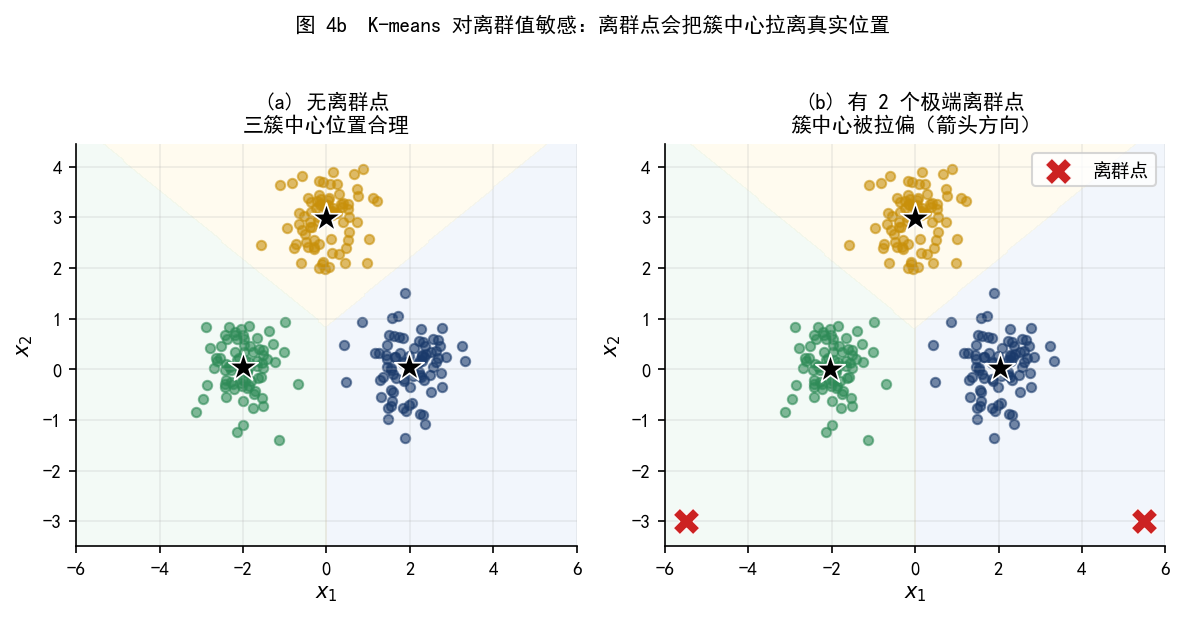

In [11]:
# ------------------------------------------------------------
# 图 04b：离群值对 K-means 的影响（新增）
# ml_cluster_fig04b_outlier
# ------------------------------------------------------------

fig_double()

# 构造一个简单的 3 簇数据集，再加入 2 个极端离群点
RNG2 = np.random.default_rng(99)
X_clean_parts = [
    RNG2.normal([-2, 0], 0.5, (80, 2)),
    RNG2.normal([2,  0], 0.5, (80, 2)),
    RNG2.normal([0,  3], 0.5, (80, 2)),
]
X_clean = np.vstack(X_clean_parts)
y_clean = np.r_[np.zeros(80), np.ones(80), np.full(80, 2)].astype(int)

# 加入 2 个极端离群点
outliers = np.array([[-5.5, -3.0], [5.5, -3.0]])
X_with_out = np.vstack([X_clean, outliers])

x_mn, x_mx = X_with_out[:,0].min()-0.5, X_with_out[:,0].max()+0.5
y_mn, y_mx = X_with_out[:,1].min()-0.5, X_with_out[:,1].max()+0.5
xx2, yy2 = np.meshgrid(np.linspace(x_mn,x_mx,250),
                        np.linspace(y_mn,y_mx,250))
bg3 = ListedColormap(['#D6E4F7','#FFF3CC','#D8F0E4'])

fig, axes = plt.subplots(1, 2)

# --- 左图：无离群点 ---
ax = axes[0]
km_clean = KMeans(n_clusters=3, n_init=20, random_state=42)
km_clean.fit(X_clean)
Z2a = km_clean.predict(np.c_[xx2.ravel(),yy2.ravel()]).reshape(xx2.shape)
ax.contourf(xx2,yy2,Z2a, levels=[-0.5,0.5,1.5,2.5],
            cmap=bg3, alpha=0.30)
for k in range(3):
    mask = km_clean.labels_ == k
    ax.scatter(X_clean[mask,0], X_clean[mask,1],
               color=PALETTE[k], alpha=0.60, s=20)
ax.scatter(km_clean.cluster_centers_[:,0],
           km_clean.cluster_centers_[:,1],
           marker='*', s=220, color='black', zorder=5,
           edgecolors='white', linewidths=0.8)
ax.set_title('(a) 无离群点\n三簇中心位置合理', fontsize=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# --- 右图：有离群点 ---
ax = axes[1]
km_out = KMeans(n_clusters=3, n_init=20, random_state=42)
km_out.fit(X_with_out)
Z2b = km_out.predict(np.c_[xx2.ravel(),yy2.ravel()]).reshape(xx2.shape)
ax.contourf(xx2,yy2,Z2b, levels=[-0.5,0.5,1.5,2.5],
            cmap=bg3, alpha=0.30)
lbls_out = km_out.labels_
for k in range(3):
    mask = lbls_out[:len(X_clean)] == k
    ax.scatter(X_clean[mask,0], X_clean[mask,1],
               color=PALETTE[k], alpha=0.60, s=20)
# 离群点用红色 X 标出
ax.scatter(outliers[:,0], outliers[:,1],
           color=PALETTE[3], marker='X', s=160, zorder=6,
           edgecolors='white', linewidths=0.5, label='离群点')
ax.scatter(km_out.cluster_centers_[:,0],
           km_out.cluster_centers_[:,1],
           marker='*', s=220, color='black', zorder=5,
           edgecolors='white', linewidths=0.8)
# 标注中心被拉偏
for k in range(3):
    c_clean = km_clean.cluster_centers_[k]
    c_out   = km_out.cluster_centers_[k]
    if np.linalg.norm(c_clean - c_out) > 0.3:
        ax.annotate('', xy=c_out, xytext=c_clean,
                    arrowprops=dict(arrowstyle='->', color=PALETTE[3],
                                    lw=1.8, mutation_scale=12))
ax.legend(fontsize=9)
ax.set_title('(b) 有 2 个极端离群点\n簇中心被拉偏（箭头方向）', fontsize=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

fig.suptitle('图 4b  K-means 对离群值敏感：离群点会把簇中心拉离真实位置',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig04b_outlier')
plt.show()

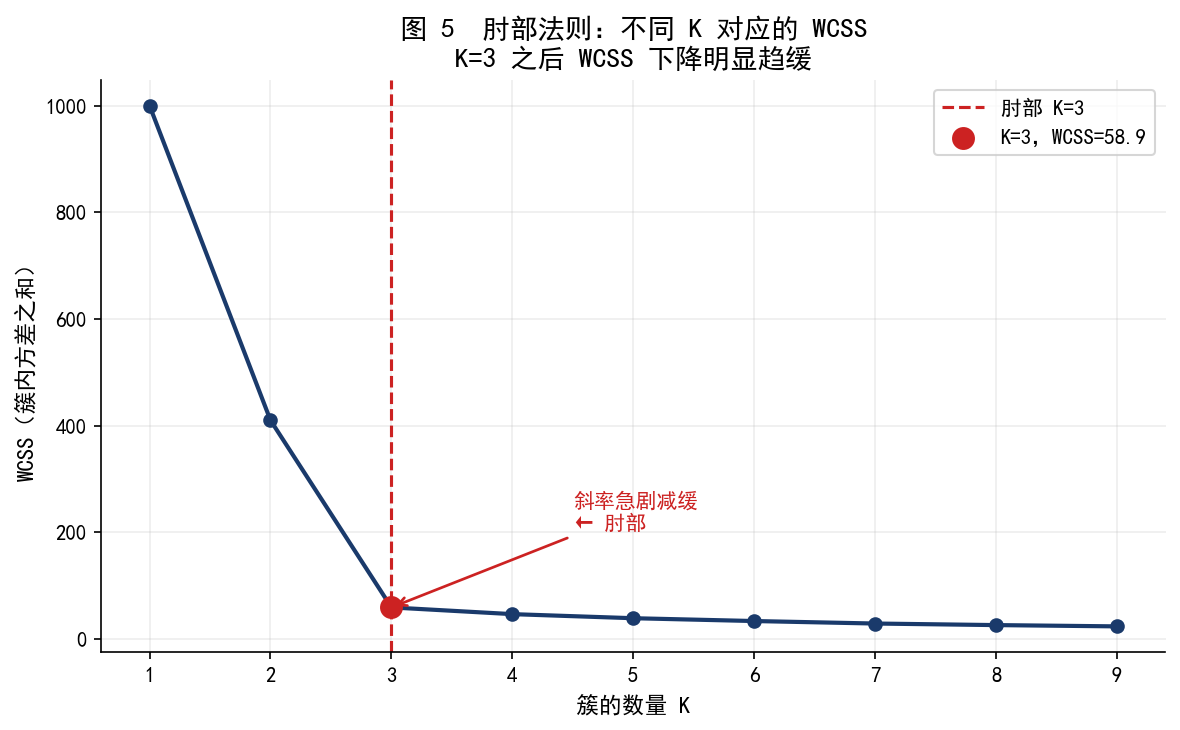

In [12]:
# ------------------------------------------------------------
# 图 05：肘部法则
# ml_cluster_fig05_elbow
# ------------------------------------------------------------

fig_single()

inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_C_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(K_range), inertias, 'o-',
        color=PALETTE[0], lw=2.0, ms=6)
ax.axvline(3, color=PALETTE[3], lw=1.5, linestyle='--',
           label='肘部 K=3')
ax.scatter([3], [inertias[2]], s=100, color=PALETTE[3], zorder=5,
           label=f'K=3，WCSS={inertias[2]:.1f}')
ax.annotate('斜率急剧减缓\n← 肘部',
            xy=(3, inertias[2]),
            xytext=(4.5, inertias[2]+(inertias[0]-inertias[-1])*0.15),
            arrowprops=dict(arrowstyle='->', color=PALETTE[3], lw=1.3),
            fontsize=10, color=PALETTE[3])
ax.set_xlabel('簇的数量 K')
ax.set_ylabel('WCSS（簇内方差之和）')
ax.set_title('图 5  肘部法则：不同 K 对应的 WCSS\n'
             'K=3 之后 WCSS 下降明显趋缓')
ax.set_xticks(list(K_range))
ax.legend(fontsize=10)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig05_elbow')
plt.show()

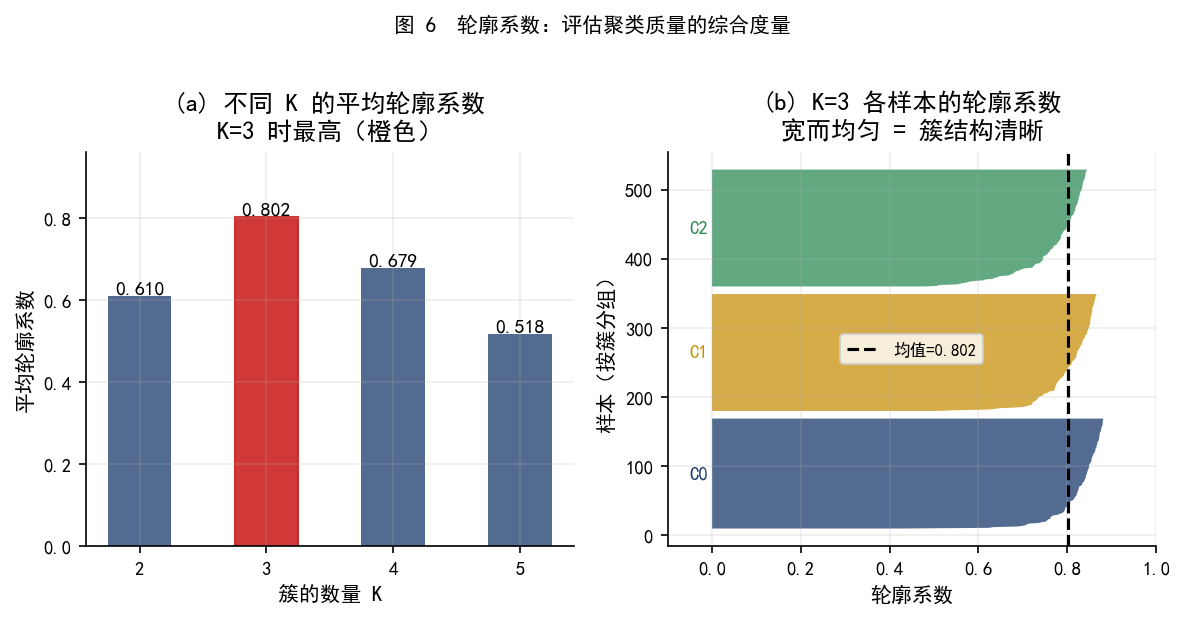

In [13]:
# ------------------------------------------------------------
# 图 06：轮廓系数图
# ml_cluster_fig06_silhouette
# ------------------------------------------------------------

fig_double()

sil_scores = {}
for k in [2,3,4,5]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    lbls = km.fit_predict(X_C_sc)
    sil_scores[k] = silhouette_score(X_C_sc, lbls)

fig, axes = plt.subplots(1, 2)

# 左图：平均轮廓系数
ax = axes[0]
ks, ss = list(sil_scores.keys()), list(sil_scores.values())
bars = ax.bar(ks, ss, color=[PALETTE[0]]*4, alpha=0.75, width=0.5)
best_k_sil = ks[np.argmax(ss)]
bars[ks.index(best_k_sil)].set_color(PALETTE[3])
bars[ks.index(best_k_sil)].set_alpha(0.9)
for bar, val in zip(bars, ss):
    ax.text(bar.get_x()+bar.get_width()/2,
            val+0.005, f'{val:.3f}', ha='center', fontsize=9.5)
ax.set_xlabel('簇的数量 K')
ax.set_ylabel('平均轮廓系数')
ax.set_title(f'(a) 不同 K 的平均轮廓系数\nK={best_k_sil} 时最高（橙色）')
ax.set_xticks(ks)
ax.set_ylim(0, max(ss)*1.2)

# 右图：K=3 逐样本轮廓系数
ax2 = axes[1]
km3 = KMeans(n_clusters=3, n_init=20, random_state=42)
lbls3 = km3.fit_predict(X_C_sc)
sil_vals = silhouette_samples(X_C_sc, lbls3)

y_lower = 10
for k in range(3):
    sil_k = np.sort(sil_vals[lbls3==k])
    y_upper = y_lower + len(sil_k)
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                       facecolor=PALETTE[k], alpha=0.75)
    ax2.text(-0.05, y_lower+len(sil_k)/2, f'C{k}',
             fontsize=9, color=PALETTE[k], va='center')
    y_lower = y_upper + 10
ax2.axvline(sil_scores[3], color='black', lw=1.5, linestyle='--',
            label=f'均值={sil_scores[3]:.3f}')
ax2.set_xlabel('轮廓系数')
ax2.set_ylabel('样本（按簇分组）')
ax2.set_title('(b) K=3 各样本的轮廓系数\n宽而均匀 = 簇结构清晰')
ax2.legend(fontsize=8)
ax2.set_xlim(-0.1, 1.0)

fig.suptitle('图 6  轮廓系数：评估聚类质量的综合度量',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig06_silhouette')
plt.show()

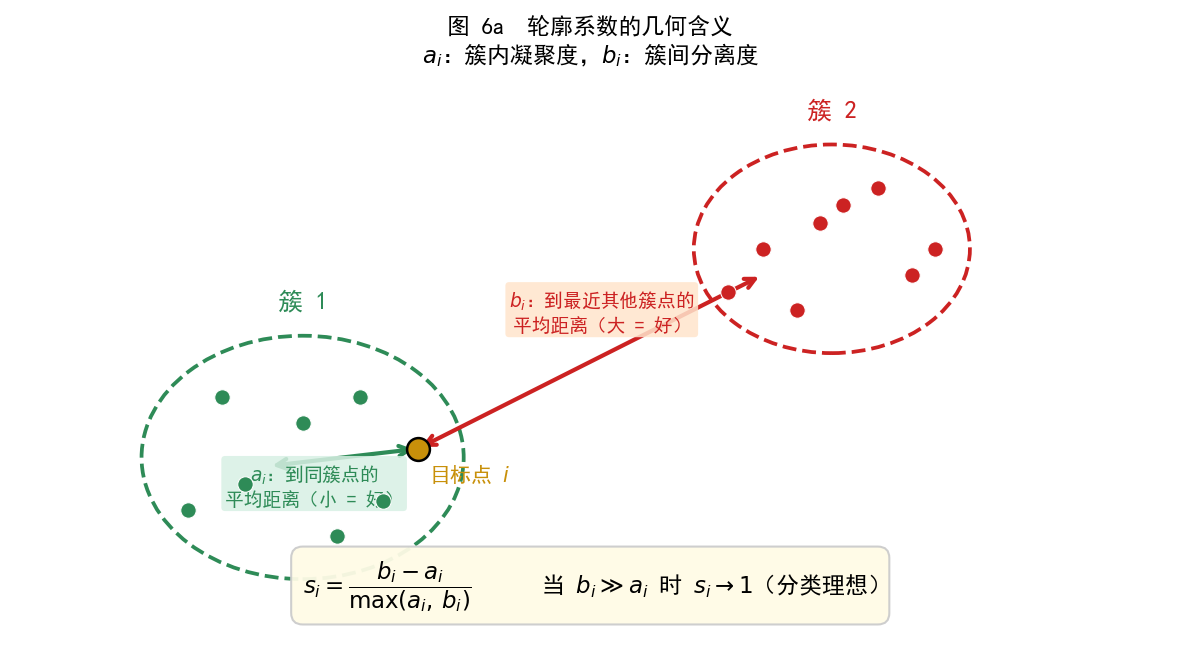

In [14]:
# ------------------------------------------------------------
# 图 06a：轮廓系数几何直觉（新增）
# ml_cluster_fig06a_sil_geometry
# ------------------------------------------------------------

fig_single()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6.5)
ax.axis('off')

# ── 簇 1（绿色，左下）──
pts1 = np.array([[2.0,1.8],[2.5,2.5],[3.2,1.6],[1.8,2.8],
                 [2.8,1.2],[3.5,2.2],[1.5,1.5],[3.0,2.8]])
ax.scatter(pts1[:,0], pts1[:,1], color=PALETTE[2], s=55, zorder=4,
           edgecolors='white', linewidths=0.5)
c1 = Circle((2.5, 2.1), 1.4, fill=False,
             edgecolor=PALETTE[2], lw=1.8, linestyle='--')
ax.add_patch(c1)
ax.text(2.5, 3.8, '簇 1', ha='center', fontsize=12,
        color=PALETTE[2], fontweight='bold')

# ── 簇 2（红色，右上）──
pts2 = np.array([[6.5,4.5],[7.2,5.0],[7.8,4.2],[6.8,3.8],
                 [7.5,5.2],[6.2,4.0],[7.0,4.8],[8.0,4.5]])
ax.scatter(pts2[:,0], pts2[:,1], color=PALETTE[3], s=55, zorder=4,
           edgecolors='white', linewidths=0.5)
c2 = Circle((7.1, 4.5), 1.2, fill=False,
             edgecolor=PALETTE[3], lw=1.8, linestyle='--')
ax.add_patch(c2)
ax.text(7.1, 6.0, '簇 2', ha='center', fontsize=12,
        color=PALETTE[3], fontweight='bold')

# ── 焦点样本（黄色，在簇1边缘）──
focus = np.array([3.5, 2.2])
ax.scatter(*focus, color=PALETTE[1], s=120, zorder=6,
           edgecolors='black', linewidths=1.2)
ax.text(focus[0]+0.1, focus[1]-0.38, '目标点 $i$',
        fontsize=10, color=PALETTE[1], fontweight='bold')

# a_i：到同簇内其他点的平均距离（画到簇1中心的箭头示意）
ax.annotate('', xy=[2.2, 2.0], xytext=focus,
            arrowprops=dict(arrowstyle='<->', color=PALETTE[2],
                            lw=2.0, mutation_scale=12))
ax.text(2.6, 1.55,
        '$a_i$：到同簇点的\n平均距离（小 = 好）',
        fontsize=9, color=PALETTE[2], ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#D8F0E4',
                  alpha=0.85, edgecolor='none'))

# b_i：到最近其他簇（簇2）所有点的平均距离
ax.annotate('', xy=[6.5, 4.2], xytext=focus,
            arrowprops=dict(arrowstyle='<->', color=PALETTE[3],
                            lw=2.0, mutation_scale=12))
mid_b = (focus + np.array([6.5, 4.2])) / 2
ax.text(mid_b[0]+0.1, mid_b[1]+0.35,
        '$b_i$：到最近其他簇点的\n平均距离（大 = 好）',
        fontsize=9, color=PALETTE[3], ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFE5CC',
                  alpha=0.85, edgecolor='none'))

# 公式框
ax.text(5.0, 0.55,
        r'$s_i = \dfrac{b_i - a_i}{\max(a_i,\, b_i)}$      '
        r'当 $b_i \gg a_i$ 时 $s_i \to 1$（分类理想）',
        ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFFBE6',
                  edgecolor='#cccccc', alpha=0.95))

ax.set_title('图 6a  轮廓系数的几何含义\n'
             '$a_i$：簇内凝聚度，$b_i$：簇间分离度', fontsize=11)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig06a_sil_geometry')
plt.show()

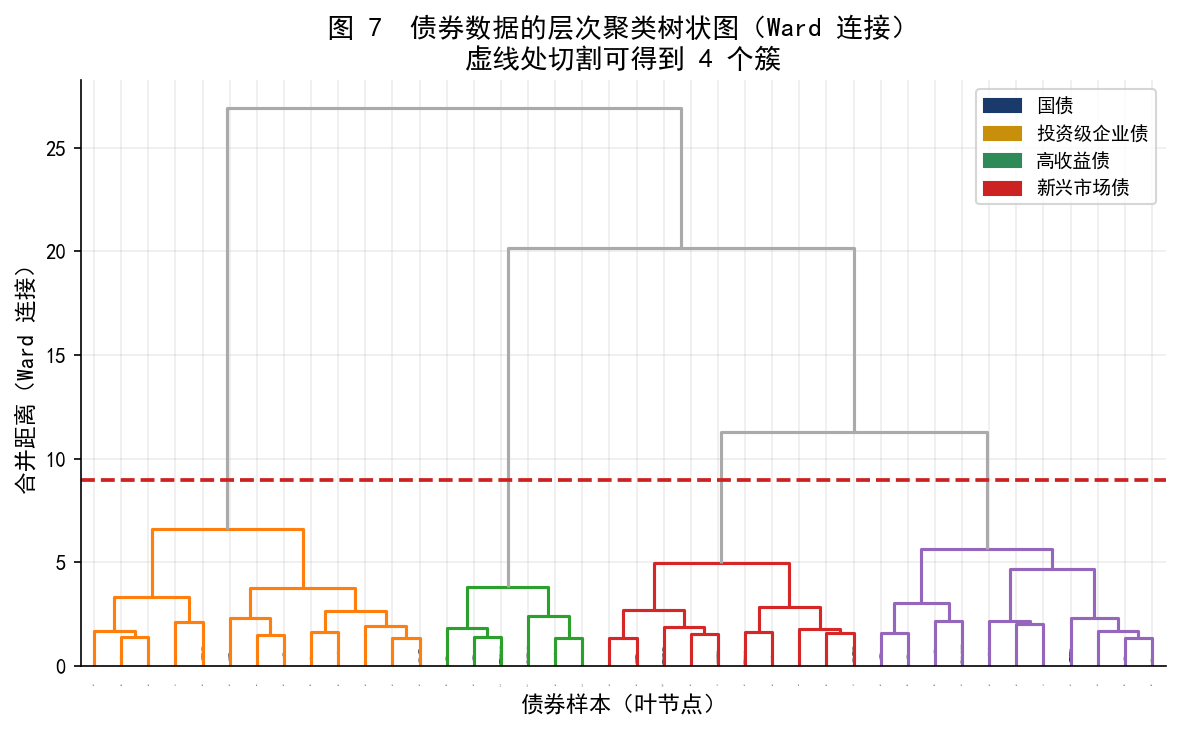

In [15]:
# ------------------------------------------------------------
# 图 07：债券数据层次聚类树状图
# ml_cluster_fig07_dendrogram
# ------------------------------------------------------------

fig_single()

fig, ax = plt.subplots(figsize=(8, 5))
dend = dendrogram(
    Z_ward, ax=ax,
    truncate_mode='lastp', p=40,
    leaf_rotation=90, leaf_font_size=0,
    color_threshold=Z_ward[-3,2],
    above_threshold_color='#aaaaaa',
    show_contracted=True,
)
cut_height = (Z_ward[-3,2] + Z_ward[-4,2]) / 2
ax.axhline(cut_height, color=PALETTE[3], lw=1.8, linestyle='--',
           label='切割高度 → 4 个簇')
patches = [mpatches.Patch(color=PALETTE[k], label=bond_names[k])
           for k in range(4)]
ax.legend(handles=patches, fontsize=9, loc='upper right')
ax.set_xlabel('债券样本（叶节点）')
ax.set_ylabel('合并距离（Ward 连接）')
ax.set_title('图 7  债券数据的层次聚类树状图（Ward 连接）\n'
             '虚线处切割可得到 4 个簇')
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig07_dendrogram')
plt.show()

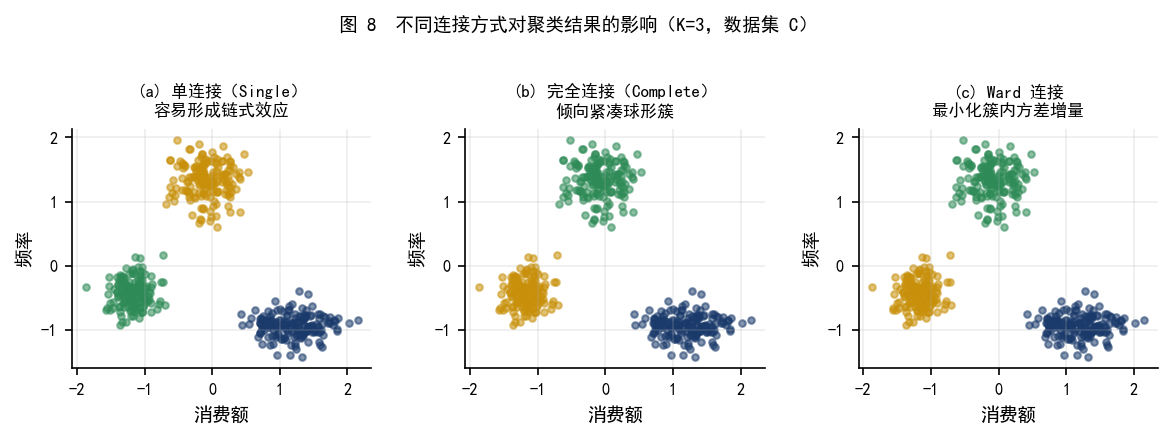

In [16]:
# ------------------------------------------------------------
# 图 08：不同连接方式对比
# ml_cluster_fig08_linkage
# ------------------------------------------------------------

fig_triple()

fig, axes = plt.subplots(1, 3)

for ax, method, title in zip(axes,
    ['single', 'complete', 'ward'],
    ['(a) 单连接（Single）\n容易形成链式效应',
     '(b) 完全连接（Complete）\n倾向紧凑球形簇',
     '(c) Ward 连接\n最小化簇内方差增量']):
    Z_lk = linkage(X_C_sc, method=method)
    lbls_lk = fcluster(Z_lk, t=3, criterion='maxclust') - 1
    for k in range(3):
        ax.scatter(X_C_sc[lbls_lk==k,0], X_C_sc[lbls_lk==k,1],
                   color=PALETTE[k], alpha=0.55, s=10)
    ax.set_title(title, fontsize=8.2)
    ax.set_xlabel('消费额'); ax.set_ylabel('频率')

fig.suptitle('图 8  不同连接方式对聚类结果的影响（K=3，数据集 C）',
             fontsize=9, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig08_linkage')
plt.show()

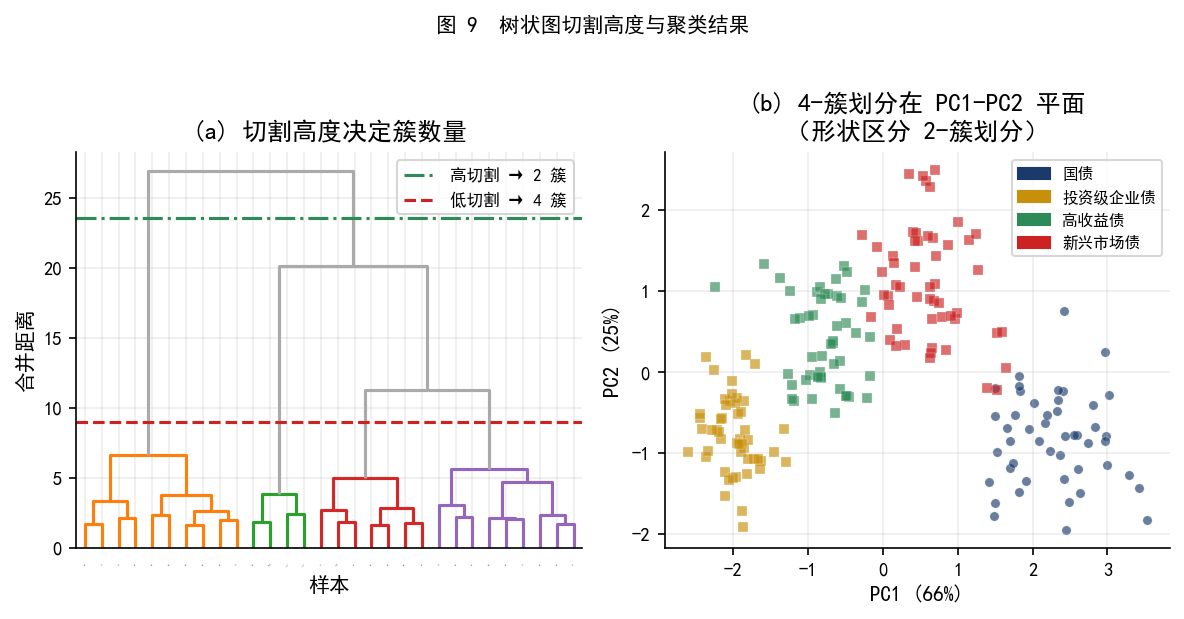

In [17]:
# ------------------------------------------------------------
# 图 09：树状图切割高度与聚类结果
# ml_cluster_fig09_cut
# ------------------------------------------------------------

fig_double()

fig, axes = plt.subplots(1, 2)

ax = axes[0]
cut2 = (Z_ward[-1,2] + Z_ward[-2,2]) / 2
cut4 = (Z_ward[-3,2] + Z_ward[-4,2]) / 2
dendrogram(Z_ward, ax=ax, truncate_mode='lastp', p=30,
           leaf_font_size=0, color_threshold=cut4,
           above_threshold_color='#aaaaaa')
ax.axhline(cut2, color=PALETTE[2], lw=1.5, linestyle='-.',
           label='高切割 → 2 簇')
ax.axhline(cut4, color=PALETTE[3], lw=1.5, linestyle='--',
           label='低切割 → 4 簇')
ax.legend(fontsize=8)
ax.set_xlabel('样本'); ax.set_ylabel('合并距离')
ax.set_title('(a) 切割高度决定簇数量')

ax2 = axes[1]
lbls_2 = fcluster(Z_ward, t=2, criterion='maxclust') - 1
lbls_4 = fcluster(Z_ward, t=4, criterion='maxclust') - 1
markers_2 = ['o','s']
for k2 in range(2):
    for k4 in range(4):
        mask = (lbls_2==k2) & (lbls_4==k4)
        if mask.sum() > 0:
            ax2.scatter(X_B_2d[mask,0], X_B_2d[mask,1],
                        color=PALETTE[k4], marker=markers_2[k2],
                        alpha=0.65, s=20,
                        edgecolors='white', linewidths=0.2)
p4 = [mpatches.Patch(color=PALETTE[k], label=bond_names[k]) for k in range(4)]
ax2.legend(handles=p4, fontsize=7.5)
ax2.set_xlabel(f'PC1 ({pca_B.explained_variance_ratio_[0]:.0%})')
ax2.set_ylabel(f'PC2 ({pca_B.explained_variance_ratio_[1]:.0%})')
ax2.set_title('(b) 4-簇划分在 PC1-PC2 平面\n（形状区分 2-簇划分）')

fig.suptitle('图 9  树状图切割高度与聚类结果',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig09_cut')
plt.show()

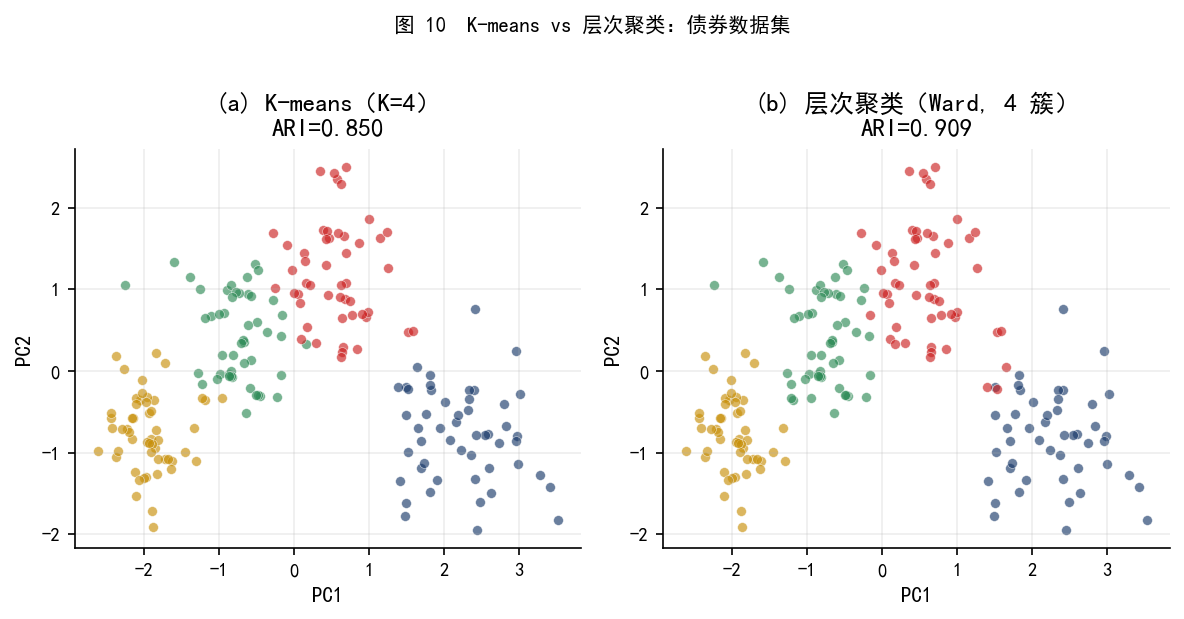

In [18]:
# ------------------------------------------------------------
# 图 10：K-means vs 层次聚类（债券数据）
# ml_cluster_fig10_compare
# ------------------------------------------------------------

fig_double()

from sklearn.metrics import adjusted_rand_score

km_B = KMeans(n_clusters=4, n_init=30, random_state=42)
lbls_km_B = km_B.fit_predict(X_B_sc)
lbls_hc_B = fcluster(Z_ward, t=4, criterion='maxclust') - 1
ari_km = adjusted_rand_score(y_B, lbls_km_B)
ari_hc = adjusted_rand_score(y_B, lbls_hc_B)

fig, axes = plt.subplots(1, 2)
for ax, lbls, title in [
    (axes[0], lbls_km_B, f'(a) K-means（K=4）\nARI={ari_km:.3f}'),
    (axes[1], lbls_hc_B, f'(b) 层次聚类（Ward, 4 簇）\nARI={ari_hc:.3f}'),
]:
    for k in range(4):
        mask = lbls == k
        ax.scatter(X_B_2d[mask,0], X_B_2d[mask,1],
                   color=PALETTE[k], alpha=0.65, s=22,
                   edgecolors='white', linewidths=0.3)
    ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
    ax.set_title(title)

fig.suptitle('图 10  K-means vs 层次聚类：债券数据集',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig10_compare')
plt.show()

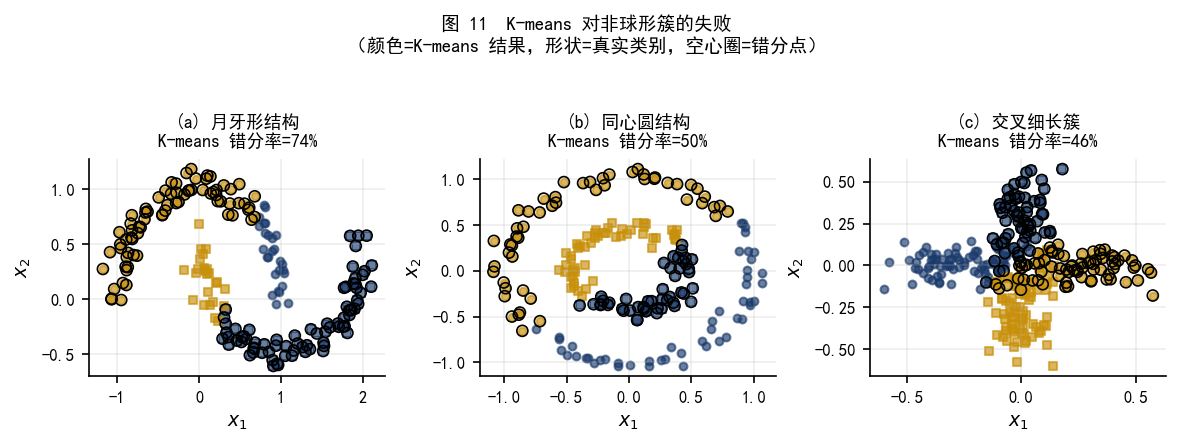

In [19]:
# ------------------------------------------------------------
# 图 11：K-means 对非球形簇的局限
# ml_cluster_fig11_nonconvex
# ------------------------------------------------------------

fig_triple()

datasets_nl = [
    (X_moon,  y_moon,  '(a) 月牙形结构'),
    (X_circ,  y_circ,  '(b) 同心圆结构'),
    (X_elong, y_elong, '(c) 交叉细长簇'),
]

fig, axes = plt.subplots(1, 3)
for ax, (X_nl, y_nl, title) in zip(axes, datasets_nl):
    k_nl = len(np.unique(y_nl))
    km_nl = KMeans(n_clusters=k_nl, n_init=20, random_state=42)
    lbls_nl = km_nl.fit_predict(X_nl)
    markers_true = ['o','s','^']
    for kt in range(k_nl):
        for kp in range(k_nl):
            mask = (y_nl==kt) & (lbls_nl==kp)
            if mask.sum() > 0:
                ax.scatter(X_nl[mask,0], X_nl[mask,1],
                           color=PALETTE[kp], marker=markers_true[kt],
                           alpha=0.65, s=14)
    wrong = y_nl != lbls_nl
    if wrong.sum() > 0:
        ax.scatter(X_nl[wrong,0], X_nl[wrong,1],
                   facecolors='none', edgecolors='black',
                   linewidths=0.8, s=28, zorder=5)
    ax.set_title(f'{title}\nK-means 错分率={wrong.mean():.0%}', fontsize=8.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

fig.suptitle('图 11  K-means 对非球形簇的失败\n'
             '（颜色=K-means 结果，形状=真实类别，空心圈=错分点）',
             fontsize=9, y=1.04)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig11_nonconvex')
plt.show()

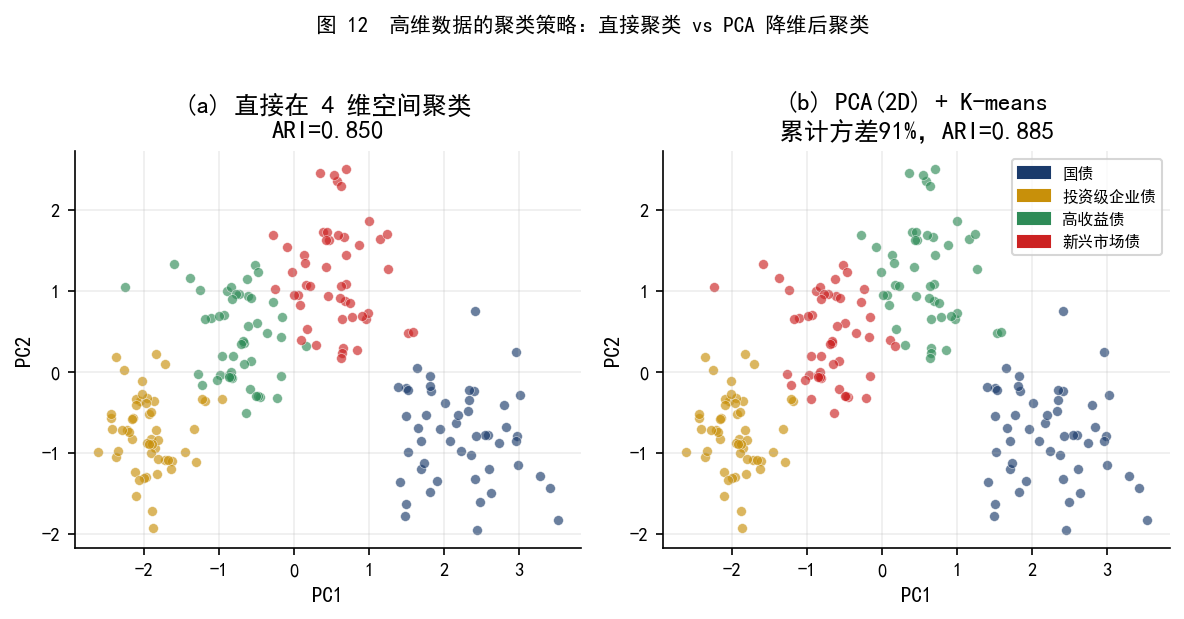

In [20]:
# ------------------------------------------------------------
# 图 12：PCA + K-means 对比
# ml_cluster_fig12_pca_cluster
# ------------------------------------------------------------

fig_double()

from sklearn.metrics import adjusted_rand_score

km_4d = KMeans(n_clusters=4, n_init=30, random_state=42)
lbls_4d = km_4d.fit_predict(X_B_sc)
ari_4d = adjusted_rand_score(y_B, lbls_4d)

km_pca2 = KMeans(n_clusters=4, n_init=30, random_state=42)
lbls_pca2 = km_pca2.fit_predict(X_B_2d)
ari_pca2 = adjusted_rand_score(y_B, lbls_pca2)
cum_var2 = pca_B.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2)
for ax, lbls, ari, title in [
    (axes[0], lbls_4d,  ari_4d,
     f'(a) 直接在 4 维空间聚类\nARI={ari_4d:.3f}'),
    (axes[1], lbls_pca2, ari_pca2,
     f'(b) PCA(2D) + K-means\n累计方差{cum_var2:.0%}，ARI={ari_pca2:.3f}'),
]:
    for k in range(4):
        mask = lbls == k
        ax.scatter(X_B_2d[mask,0], X_B_2d[mask,1],
                   color=PALETTE[k], alpha=0.65, s=22,
                   edgecolors='white', linewidths=0.3)
    ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
    ax.set_title(title)
patches = [mpatches.Patch(color=PALETTE[k], label=bond_names[k])
           for k in range(4)]
axes[1].legend(handles=patches, fontsize=7.5)
fig.suptitle('图 12  高维数据的聚类策略：直接聚类 vs PCA 降维后聚类',
             fontsize=10, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_cluster_fig12_pca_cluster')
plt.show()